# Modifications Necessary from Original Work 

In [9]:
import os
import cv2
import sqlite3
import numpy as np
import json

from fogvis.preprocessing.image import calculate_grey_normal_distribution
from fogvis.preprocessing.subregion import select_subregions

from matplotlib import pyplot as plt
from pathlib import Path
from fogvis.db import ImageEntity, Database
from scipy.stats import norm 
from dataclasses import dataclass, asdict

PRE_MASK_GREY_VALUE_CLIP = 245
NUM_SUBREGIONS_TO_SELECT = 5
GLOBAL_CANDIDATE_T_VALUES = [235]

## Subregion Selection

The original work selects subregions from greyscale average image through a manually selected cutoff value. This was acceptable because that work only focused on one camera angle. This adaptation of the work involves hundreds of camera angles and different environments for each camera angle. This difference causes issues when only one T value is selected for a single camera angle.

This is especially apparent when comparing linear fog rendering against marched rendering. The linear fog rendering approach causes the sky to have a solid white color. Whereas marched fog results in some grey to the sky. This shifts the data layout between the two.

In [ ]:
def draw_subregions(image, subregions, selected_t, color=(0, 0, 255), thickness=2):
    """
    Draw horizontal subregions over an image.

    image:
        grayscale or BGR image

    subregions:
        list of (y0, y1) tuples

    color:
        rectangle color in BGR.
        Default (0, 0, 255) = red.

    thickness:
        line thickness
    """

    # Convert grayscale to BGR so colored rectangles can be drawn
    if len(image.shape) == 2:
        output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        output = image.copy()

    height, width = output.shape[:2]

    for i, (x0, y0, x1, y1) in enumerate(subregions):
        # Draw rectangle spanning full image width
        cv2.rectangle(
            output,
            (x0, y0),
            (x1, y1),
            color,
            thickness
        )
    
    overlay_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(overlay_rgb)
    plt.title(f"Selected subregions, T={selected_t}")
    plt.axis("off")
    plt.show()

def plot_normal_distribution(img, mean, std, max_clip) -> None: 
    pixels = img.ravel()

    # Create histogram
    plt.figure(figsize=(8, 5))

    plt.hist(
        pixels,
        bins=256,
        range=(0, max_clip),
        density=True,
        alpha=0.6,
        color="gray",
        label="Greyscale histogram"
    )

    # Create normal distribution curve
    x = np.linspace(0, 255, 256)
    gaussian_curve = norm.pdf(x, mean, std)

    # Plot Gaussian curve
    plt.plot(
        x,
        gaussian_curve,
        color="red",
        linewidth=2,
        label=f"Normal fit\nμ={mean:.2f}, σ={std:.2f}"
    )
    plt.show()

#### Linear Fog

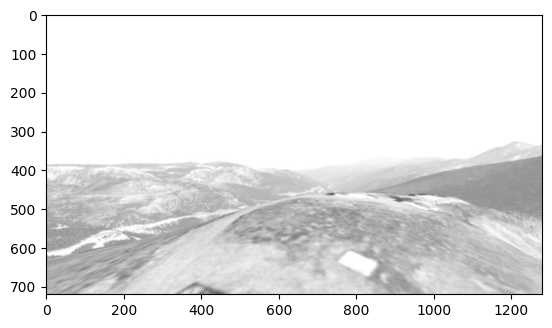

In [11]:
grey_avg_fog_linear_file = os.path.join(os.getcwd(), "media", "1.jpg")
lin_img = cv2.imread(grey_avg_fog_linear_file, cv2.IMREAD_GRAYSCALE)
if lin_img is None:
    raise Exception("Failed to open image")

plt.imshow(lin_img, cmap="grey", vmin=0, vmax=255)
plt.show()


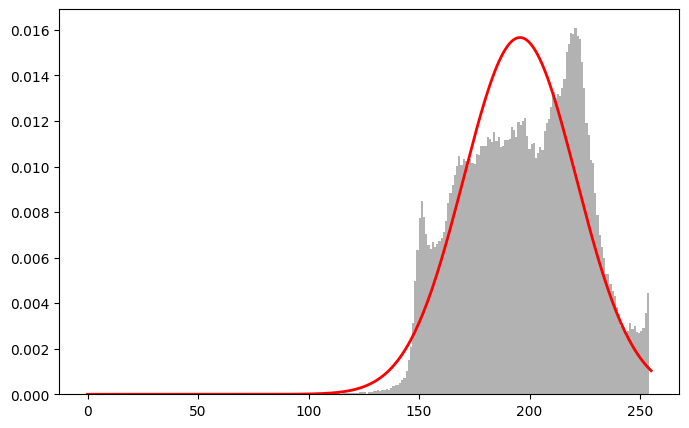

In [12]:
white_mask = lin_img.ravel() < PRE_MASK_GREY_VALUE_CLIP
mean,std = calculate_grey_normal_distribution(lin_img, white_mask)
plot_normal_distribution(lin_img, mean, std, 254)

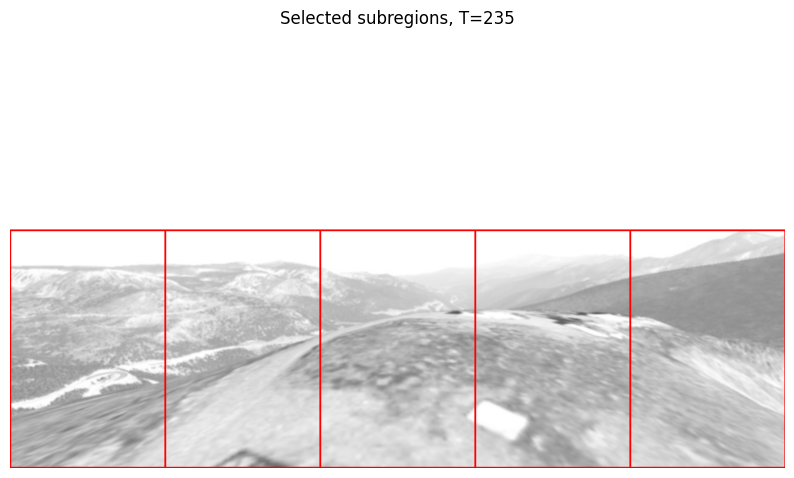

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[  0,   0, 255],
        [  0,   0, 255],
        [183, 183, 183],
        ...,
        [209, 209, 209],
        [210, 210, 210],
        [  0,   0, 255]],

       [[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]],

       [[  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255],
        ...,
        [  0,   0, 255],
        [  0,   0, 255],
        [  0,   0, 255]]

In [13]:
subregions, selected_t = select_subregions(lin_img, 5, GLOBAL_CANDIDATE_T_VALUES)
draw_subregions(lin_img, subregions, selected_t)

#### Marched Fog

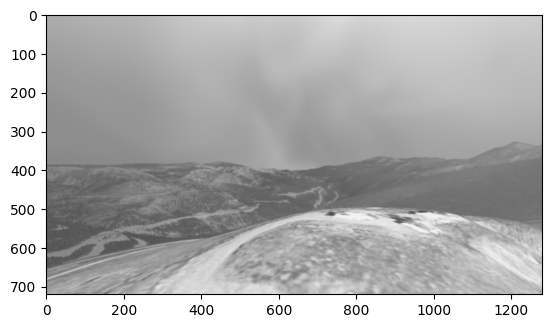

In [6]:
grey_avg_fog_marched_file = os.path.join(os.getcwd(), "media", "1441.jpg")
marched_img = cv2.imread(grey_avg_fog_marched_file, cv2.IMREAD_GRAYSCALE)
if marched_img is None:
    raise Exception("Failed to open image")

plt.imshow(marched_img, cmap="grey", vmin=0, vmax=255)
plt.show()


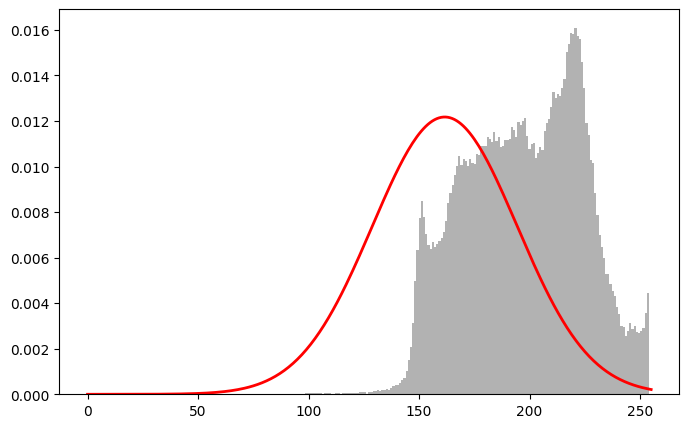

In [7]:
white_mask = marched_img.ravel() < PRE_MASK_GREY_VALUE_CLIP
mean,std = calculate_grey_normal_distribution(marched_img, white_mask)
plot_normal_distribution(lin_img, mean, std, 254)